layers.0:Linear              [output] shape=(100, 1024, 40, 64) min=-3.5269 p5=-1.1225 mean=-0.0492 std=+0.6587 p95=+1.0367 max=+3.1673 zero=  0.0% nan= 0.0% inf= 0.0%
layers.1:ReLU                [output] shape=(100, 1024, 40, 64) min=+0.0000 p5=+0.0000 mean=+0.2353 std=+0.3737 p95=+1.0367 max=+3.1673 zero= 53.5% nan= 0.0% inf= 0.0%
layers.2:Linear              [output] shape=(100, 1024, 40, 64) min=-1.7654 p5=-0.4601 mean=+0.0221 std=+0.2929 p95=+0.4963 max=+1.9024 zero=  0.0% nan= 0.0% inf= 0.0%
layers.3:ReLU                [output] shape=(100, 1024, 40, 64) min=+0.0000 p5=+0.0000 mean=+0.1240 std=+0.1781 p95=+0.4963 max=+1.9024 zero= 45.3% nan= 0.0% inf= 0.0%
layers.4:Linear              [output] shape=(100, 1024, 40, 1) min=-0.7450 p5=-0.3771 mean=-0.2509 std=+0.0642 p95=-0.1785 max=-0.1610 zero=  0.0% nan= 0.0% inf= 0.0%
layers.5:Softplus            [output] shape=(100, 1024, 40, 1) min=+0.3885 p5=+0.5223 mean=+0.5761 std=+0.0275 p95=+0.6079 max=+0.6159 zero=  0.0% nan= 0.0% inf=

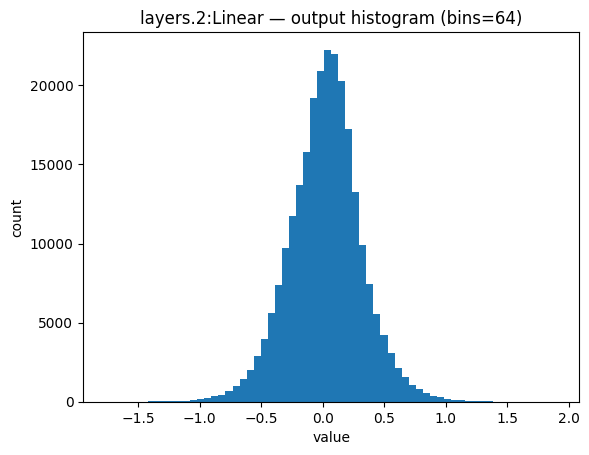

In [1]:
from nerflab.nerf_sigma_learning.learning_utils.layer_probe import LayerProbe
import torch, torch.nn as nn

class Tiny_Nerf(nn.Module):
    def __init__(self, in_features=3, out_features=1):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(),
            nn.Linear(64, 64),          nn.ReLU(),
            nn.Linear(64, out_features), nn.Softplus()
        )
    def forward(self, x): return self.layers(x).squeeze(-1)

model = Tiny_Nerf()

probe = LayerProbe(
    capture="both",
    bins=64,
    history_max=3,
    print_every=0,
    max_elems=250_000,         # <- key for big tensors
    sample_mode="uniform",     # or "random"
    handle_tuple_outputs=False # set True if your modules return (y, aux,...)
)

probe.register_on(model)               # hooks leafs; root too if single-module
_ = model(torch.randn(100, 1024, 40, 3))
print(probe.table())
probe.plot_hist("layers.2:Linear", which="output")

probe.clear()
probe.unregister()


In [2]:
# TEST = True
# if TEST:
#   C_true, delta, pts = get_batch_rays(debug=False)
#   model = Tiny_Nerf()
#   print(model.parameters)

#   print(f"pts shape: {pts.shape}")
#   print(f"min pts: {torch.min(pts)}    max pts: {torch.max(pts)}")
#   sigma = model(pts)
#   print(f"sigma shape: {sigma.shape}")
#   C_hat = nerf_opacity(sigma, delta, full_output=False)
#   # C_hat = compute_opacity_simple(sigma, delta)
#   print(f"C_hat shape: {C_hat.shape}")
#   print(f"C_true shape: {C_true.shape}")
#   # print(C_hat)
#   print(f"MSE Loss: {mse_loss(C_hat, C_true):+.04f}")
  
#   # -----------------------------
#   # Hook utility
#   # -----------------------------
# #   def summary_hook(name, output_flag = True):
# #       def hook(module, input, output):
# #           if output_flag:
# #             interest = output
# #           else:
# #             interest = input[0]
# #           if isinstance(interest, torch.Tensor):
# #               print(f"\n--- {name} ---")
# #               print(f"shape : {tuple(interest.shape)}")
# #               print(f"min   : {interest.min().item():.4f}")
# #               print(f"max   : {interest.max().item():.4f}")
# #               print(f"mean  : {interest.mean().item():.4f}")
# #               print(f"std   : {interest.std().item():.4f}")
# #           return None
# #       return hook
    
# # # Attach hooks to every layer
# # for name, layer in model.layers.named_children():
# #     layer.register_forward_hook(summary_hook(f"Layer {name}: {layer.__class__.__name__}", output_flag=False))

# from collections import defaultdict

# class LayerStats:
#     def __init__(self):
#         self.data = defaultdict(list)

#     def hook(self, tag):
#         def _hook(module, inp, out):
#             if isinstance(out, torch.Tensor):
#                 t = out.detach()
#                 self.data[tag].append({
#                     "shape": tuple(t.shape),
#                     "min": t.min().item(),
#                     "max": t.max().item(),
#                     "mean": t.mean().item(),
#                     "std": t.std().item(),
#                 })
#         return _hook

#     def table(self):
#         # compact text table per layer (latest pass)
#         lines = []
#         for tag, records in self.data.items():
#             r = records[-1]  # latest
#             lines.append(
#                 f"{tag:<24} shape={r['shape']!s:<14} "
#                 f"min={r['min']:+.4f} max={r['max']:+.4f} "
#                 f"mean={r['mean']:+.4f} std={r['std']:+.4f}"
#             )
#         return "\n".join(lines)

# stats = LayerStats()
# for name, layer in model.layers.named_children():
#     layer.register_forward_hook(stats.hook(f"{name}:{layer.__class__.__name__}"))

# y = model(pts)

# print(stats.table())

# # Dummy input (10 random 3D points)
# # x = torch.randn(3, 10, 3)

# # print("\nFinal output:", y)